# Reasoning and Rationale Tag Regressions

In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path

import pandas as pd
from IPython.display import display, Markdown

from shared.plot_utilities import setup_notebook_display
from shared.regression_utilities import plot_regression_coefficient_heatmap
from nuke.utils.load_replay_data import (
    _KNOWN_CONDITIONS,
    CONDITION_FACTORS as REPLAY_CONDITION_FACTORS,
    REPLAY_TAG_JOIN_KEYS,
    canonical_condition_name,
    add_canonical_replay_model,
    add_condition_factor_columns,
    filter_complete_replay_models,
    load_replay_data,
    prefixed_tier_columns,
    tier_source_columns,
)

setup_notebook_display()

TIERS = [
    'Explicit',
    "Crisis_Urgency",
    'Simulation_Game',
]

TRAILS_DIR = Path('trails')
CONDITION_ORDER = list(_KNOWN_CONDITIONS)
GROUP_COLS = ['game_id', 'player_id']
OUTCOME = 'replay_use_nuke_delta'


## Load Tagged Trails and Replay Metadata

In [2]:
rat = pd.read_csv(TRAILS_DIR / 'rationale_trails_tagged.csv')
rea = pd.read_csv(TRAILS_DIR / 'reasoning_trails_tagged.csv')

for frame in (rat, rea):
    frame = add_canonical_replay_model(frame)
    frame['condition'] = frame['condition'].map(canonical_condition_name)
    frame['condition'] = pd.Categorical(frame['condition'], categories=CONDITION_ORDER, ordered=True)

replay = load_replay_data()
replay = add_canonical_replay_model(replay)
replay, MODEL_ORDER = filter_complete_replay_models(replay)
replay['condition'] = pd.Categorical(replay['condition'], categories=CONDITION_ORDER, ordered=True)

TIER_SOURCE_COLS = tier_source_columns(TIERS)
rat_tier_cols = prefixed_tier_columns(TIERS, 'rat')
rea_tier_cols = prefixed_tier_columns(TIERS, 'rea')

rat_tags = rat[REPLAY_TAG_JOIN_KEYS + TIER_SOURCE_COLS].rename(
    columns=dict(zip(TIER_SOURCE_COLS, rat_tier_cols))
)
rea_tags = rea[REPLAY_TAG_JOIN_KEYS + TIER_SOURCE_COLS].rename(
    columns=dict(zip(TIER_SOURCE_COLS, rea_tier_cols))
)

merged = replay.merge(rat_tags, on=REPLAY_TAG_JOIN_KEYS, how='left')                .merge(rea_tags, on=REPLAY_TAG_JOIN_KEYS, how='left')
merged[rat_tier_cols + rea_tier_cols] = merged[rat_tier_cols + rea_tier_cols].fillna(0).astype(int)

print(f'Full replay rows after complete-model filter: {len(replay):,}')
print(f'After left-join:  {len(merged):,}')
print(f'Rationale tag coverage: {(merged[rat_tier_cols].any(axis=1).sum()):,} / {len(merged):,}')
print(f'Reasoning tag coverage: {(merged[rea_tier_cols].any(axis=1).sum()):,} / {len(merged):,}')
print(f'Models (complete catalog order): {MODEL_ORDER}')


✓ Loaded 37,440 rows from 96 files
  Conditions   : original, no-rationale, high-stakes, high-stakes-no-rationale, ethical, ethical-high-stakes, ethical-no-rationale, high-stakes-no-rationale-ethical
  Replay models: DeepSeek-V3.2, DeepSeek-V4, GLM-4.7, GLM-5.1, Gemma-4, Kimi-K2.5, Kimi-K2.6, MiniMax-M2.7, Mistral-Small-4, Qwen-3.5, Qwen-3.6-27B, gpt-oss-120b

  Rows per condition × replay model:
  ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                        DeepSeek-V3.2      DeepSeek-V4          GLM-4.7          GLM-5.1          Gemma-4        Kimi-K2.5        Kimi-K2.6     MiniMax-M2.7  Mistral-Small-4         Qwen-3.5     Qwen-3.6-27B     gpt-oss-120b            Total
  ──────────────────────────────────────────────────────────────────────────────────

## Tag-to-Delta Coefficient Heatmaps

### 1. Rationale only

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:408: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


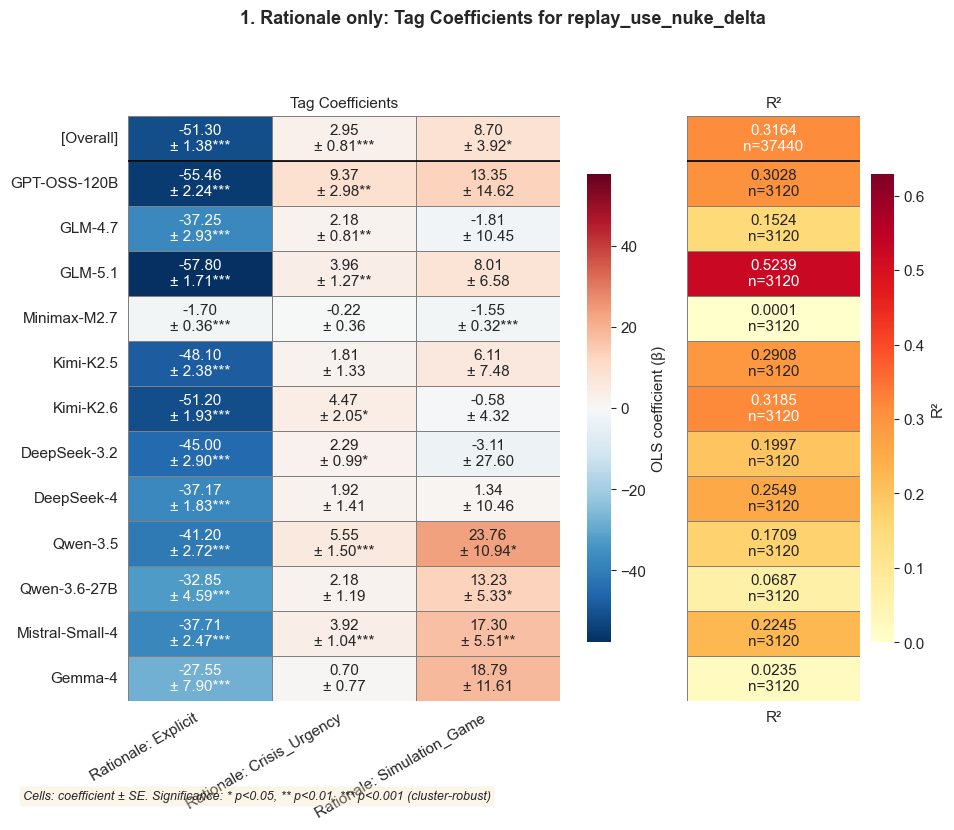

### 2. Reasoning only

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:408: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


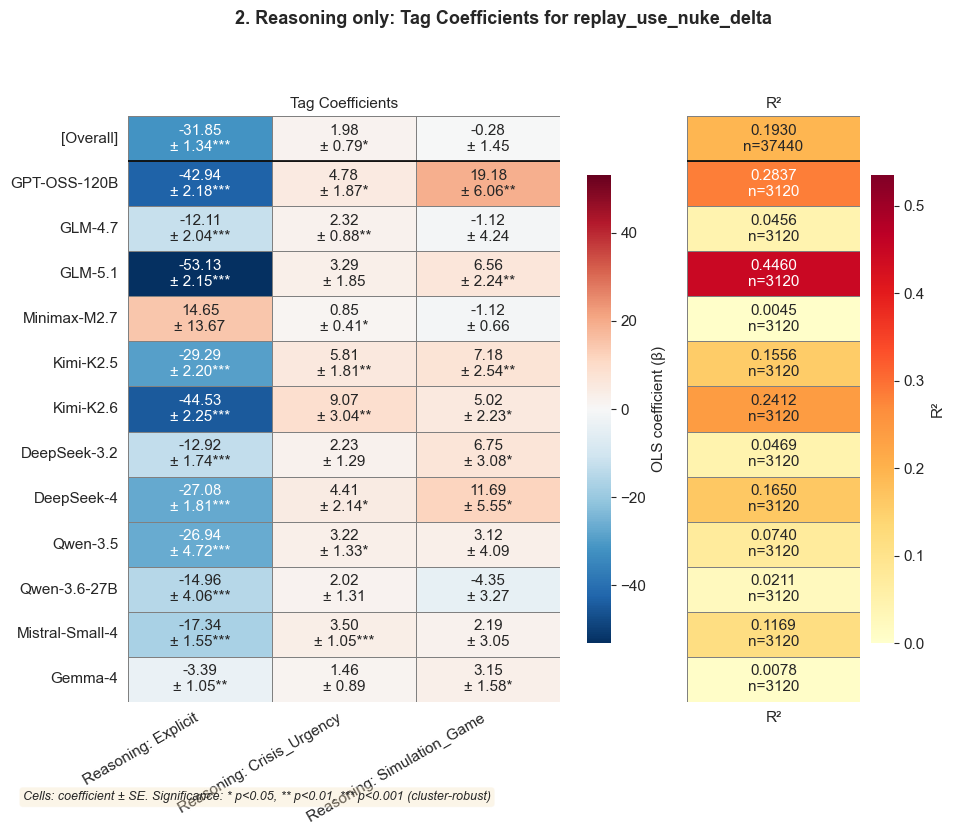

### 3. Both

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:408: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


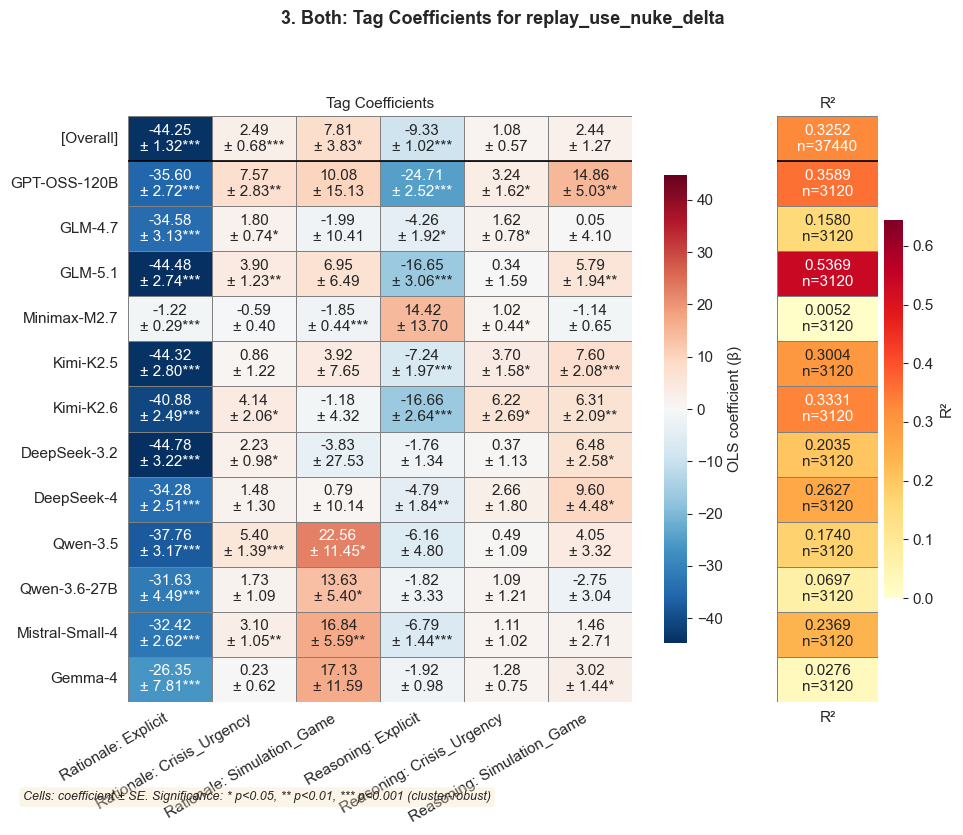

In [3]:
rea_display = dict(zip(rea_tier_cols, [f'Reasoning: {tier}' for tier in TIERS]))
rat_display = dict(zip(rat_tier_cols, [f'Rationale: {tier}' for tier in TIERS]))

specs = {
    '1. Rationale only': {
        'predictors': rat_tier_cols,
        'labels': rat_display,
    },
    '2. Reasoning only': {
        'predictors': rea_tier_cols,
        'labels': rea_display,
    },
    '3. Both': {
        'predictors': rat_tier_cols + rea_tier_cols,
        'labels': {**rat_display, **rea_display},
    },
}

for label, spec in specs.items():
    predictors = spec['predictors']
    formula = f'{OUTCOME} ~ ' + ' + '.join(predictors)
    display(Markdown(f'### {label}'))
    plot_regression_coefficient_heatmap(
        data=merged,
        outcome=OUTCOME,
        predictors=predictors,
        group_cols=GROUP_COLS,
        model_order=MODEL_ORDER,
        formula=formula,
        predictor_labels=spec['labels'],
        title=f'{label}: Tag Coefficients for {OUTCOME}',
        coefficient_title='Tag Coefficients',
        figsize=(max(10, len(predictors) * 1 + 4), max(5, len(MODEL_ORDER) * 0.45 + 2.2)),
    )

## Condition → Tag Presence (Ethical Subset)

Within the four **ethical** conditions we have a balanced 2×2 factorial:
`tag ~ no_rationale + high_stakes + no_rationale:high_stakes`

Baseline = `ethical` (no high-stakes, with rationale). This avoids the near-zero baseline prevalence that makes coefficients unstable in the full 8-condition design.

Cells show log-odds coefficients (β ± SE). Positive = condition increases tag presence, negative = decreases.

In [4]:
from shared.regression_utilities import plot_logistic_odds_ratio_heatmap

# Decompose conditions into binary factors
merged = add_condition_factor_columns(merged)

# Subset to ethical conditions only (2x2: no_rationale x high_stakes)
ethical_merged = merged[merged['ethical'] == 1].copy()

EXPLICIT_CONDITION_FACTORS = [factor for factor in REPLAY_CONDITION_FACTORS if factor != 'ethical']
EXPLICIT_INTERACTION_TERMS = []
EXPLICIT_PREDICTORS = EXPLICIT_CONDITION_FACTORS + EXPLICIT_INTERACTION_TERMS

NON_EXPLICIT_CONDITION_FACTORS = REPLAY_CONDITION_FACTORS
NON_EXPLICIT_INTERACTION_TERMS = [ ]
NON_EXPLICIT_PREDICTORS = NON_EXPLICIT_CONDITION_FACTORS + NON_EXPLICIT_INTERACTION_TERMS
PREDICTOR_LABELS = {
    'no_rationale': 'No Rationale',
    'high_stakes': 'High Stakes',
    'ethical': 'Ethical',
    'no_rationale:high_stakes': 'No Rat x HS',
    'no_rationale:ethical': 'No Rat x Ethical',
    'high_stakes:ethical': 'HS x Ethical',
    'no_rationale:high_stakes:ethical': 'No Rat x HS x Ethical',
}

print(f'Ethical subset: {len(ethical_merged):,} rows')
print(f'Conditions: {sorted(ethical_merged["condition"].unique())}')


Ethical subset: 18,720 rows
Conditions: ['ethical', 'ethical-high-stakes', 'ethical-no-rationale', 'high-stakes-no-rationale-ethical']


### Rationale Tags

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:961: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


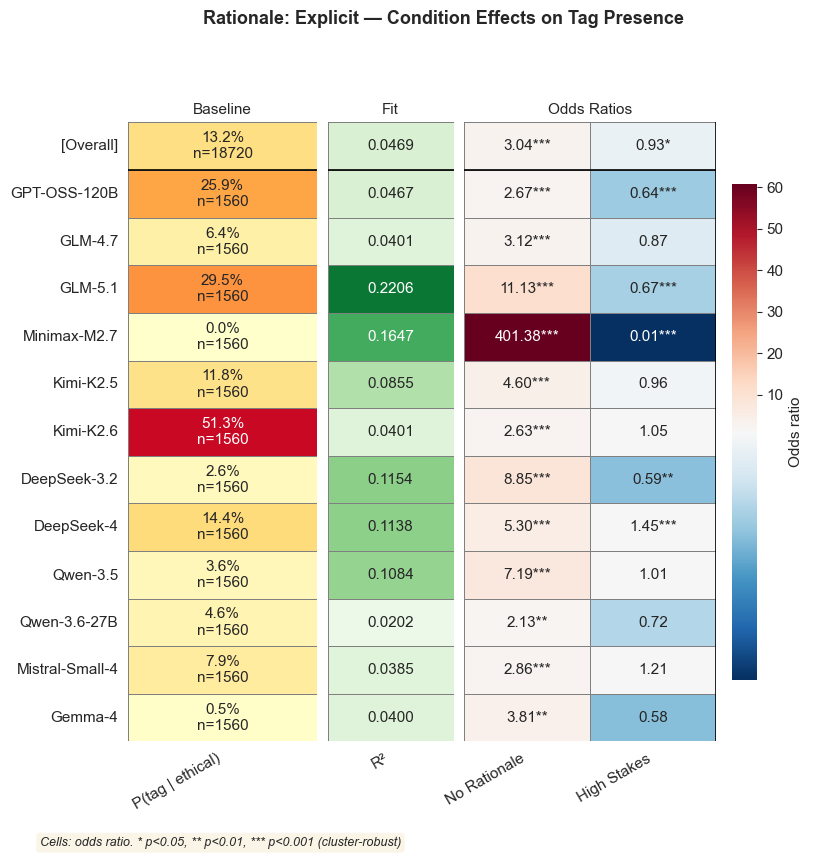

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:961: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


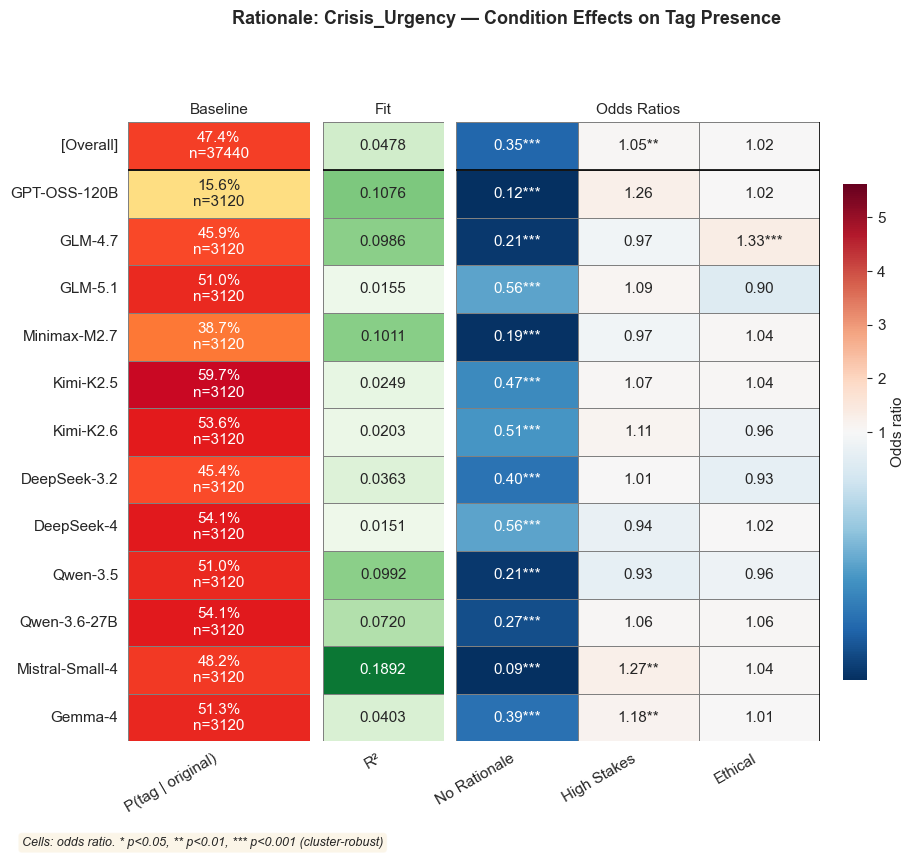

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:961: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


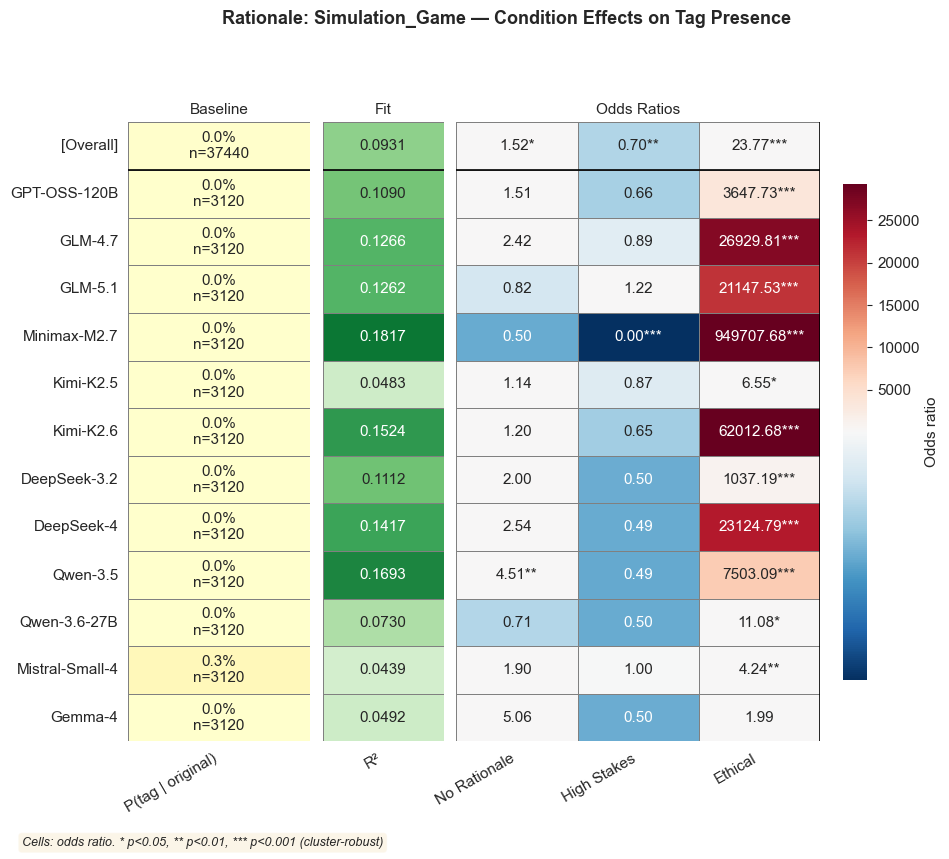

In [5]:
display(Markdown('### Rationale Tags'))

for tier, tag_col in zip(TIERS, rat_tier_cols):
    is_explicit = tier == 'Explicit'
    plot_logistic_odds_ratio_heatmap(
        data=ethical_merged if is_explicit else merged,
        outcome=tag_col,
        outcome_label=f'Rationale: {tier}',
        predictors=EXPLICIT_PREDICTORS if is_explicit else NON_EXPLICIT_PREDICTORS,
        main_predictors=EXPLICIT_CONDITION_FACTORS if is_explicit else NON_EXPLICIT_CONDITION_FACTORS,
        interaction_predictors=EXPLICIT_INTERACTION_TERMS if is_explicit else NON_EXPLICIT_INTERACTION_TERMS,
        group_cols=GROUP_COLS,
        model_order=MODEL_ORDER,
        predictor_labels=PREDICTOR_LABELS,
        **({'baseline_condition': 'ethical'} if is_explicit else {}),
    )

### Reasoning Tags

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:961: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


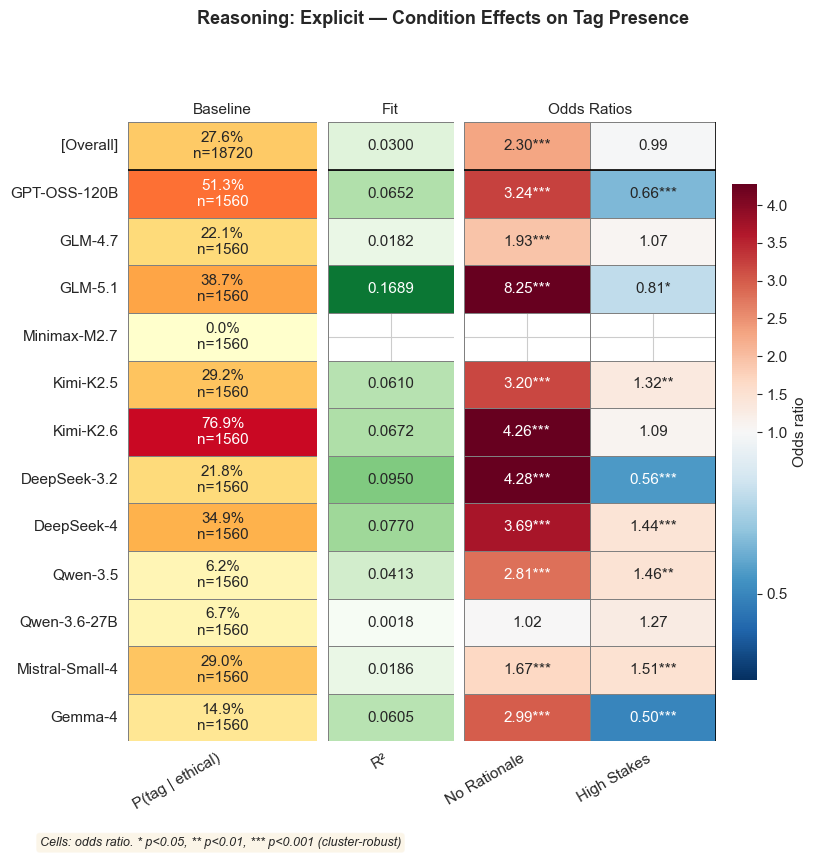

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:961: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


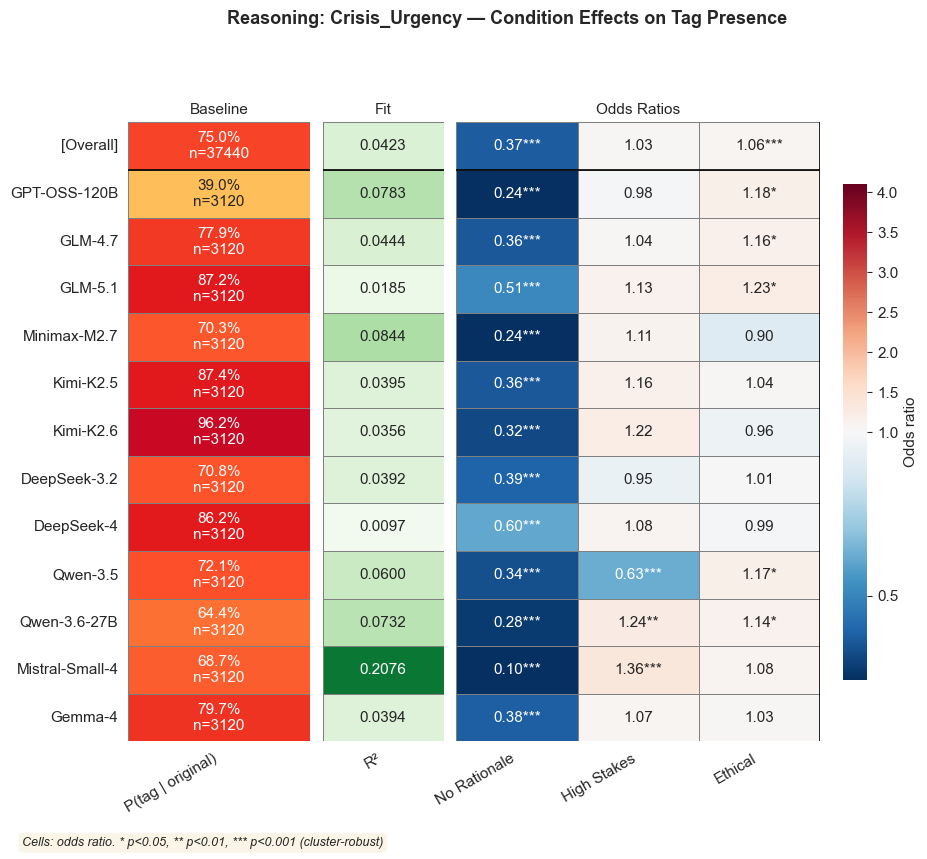

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:961: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


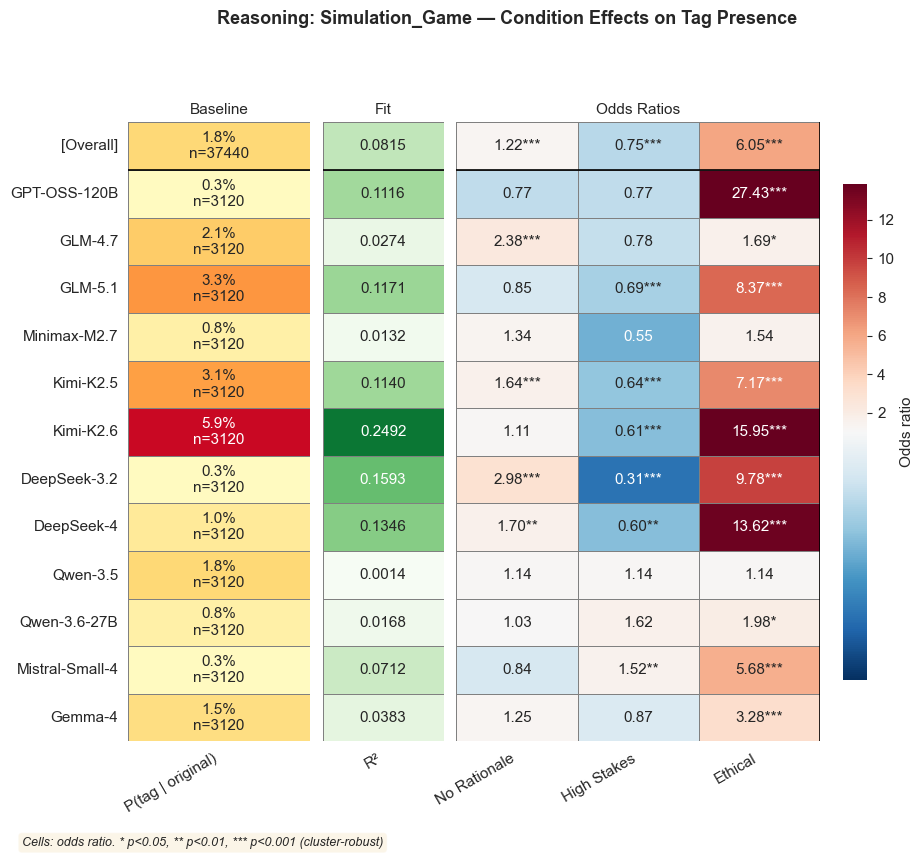

In [6]:
display(Markdown('### Reasoning Tags'))

for tier, tag_col in zip(TIERS, rea_tier_cols):
    is_explicit = tier == 'Explicit'
    plot_logistic_odds_ratio_heatmap(
        data=ethical_merged if is_explicit else merged,
        outcome=tag_col,
        outcome_label=f'Reasoning: {tier}',
        predictors=EXPLICIT_PREDICTORS if is_explicit else NON_EXPLICIT_PREDICTORS,
        main_predictors=EXPLICIT_CONDITION_FACTORS if is_explicit else NON_EXPLICIT_CONDITION_FACTORS,
        interaction_predictors=EXPLICIT_INTERACTION_TERMS if is_explicit else NON_EXPLICIT_INTERACTION_TERMS,
        group_cols=GROUP_COLS,
        model_order=MODEL_ORDER,
        predictor_labels=PREDICTOR_LABELS,
        **({'baseline_condition': 'ethical'} if is_explicit else {}),
    )